# 02 · Lineup Score para predicción W/L

Este notebook construye la feature **LINEUP_SCORE_DIFF** combinando quality individual (on/off) y sinergia histórica de alineaciones.\n
- Inputs: dashboards de lineups, on/off por jugador y boxscore tradicional.\n
- Importante: asegurar dtypes (TEAM_ID/PLAYER_ID int64, GAME_ID string) y respetar el formato `-p1-p2-p3-p4-p5-` de `GROUP_ID`.\n
- El flujo evita fuga temporal trabajando con información post-partido.


In [28]:
# Parámetros y rutas
from pathlib import Path
import pandas as pd
import numpy as np
import importlib.util

PARAMS = dict(
    m0_player_minutes=400,
    M0_lineup_minutes=300,
    alpha_quality=0.75,
    winsor_limits=(0.05, 0.95),
)
PATHS = dict(
    lineups="/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/dashboards/team_dash_lineups__dataset_1.parquet",
    on="/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/dashboards/team_player_on_off__dataset_1.parquet",
    off="/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/dashboards/team_player_on_off__dataset_2.parquet",
    boxscore="/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/boxscores.parquet",
    out="/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/features/lineup_scores.parquet",
)

def _load_feature_module():
    module_path = Path('/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/02_FeatureFunctions.py')

    if not module_path.exists():
        raise FileNotFoundError(f"No se encuentra el archivo: {module_path}")

    spec = importlib.util.spec_from_file_location('feature_functions', module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

feature_mod = _load_feature_module()
print('Funciones de features cargadas desde', feature_mod.__file__)

Funciones de features cargadas desde /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/02_FeatureFunctions.py


In [29]:
# Carga & saneo
dfs = {}
for key in ['lineups', 'on', 'off', 'boxscore']:
    path = Path(PATHS[key])
    if not path.exists():
        print(f'⚠️ No encuentro {key}: {path}')
        continue
    dfs[key] = pd.read_parquet(path)
    if 'game_id' in dfs[key].columns:
        dfs[key] = dfs[key].drop(columns=['game_id'])
    if 'GAME_ID' in dfs[key].columns:
        dfs[key]['GAME_ID'] = dfs[key]['GAME_ID'].astype('string')
    for col in ['TEAM_ID', 'PLAYER_ID']:
        if col in dfs[key].columns:
            dfs[key][col] = pd.to_numeric(dfs[key][col], errors='coerce').astype('Int64')
    print(f"{key} -> shape {dfs[key].shape}")
    display(dfs[key].dtypes)
    display(dfs[key].head())

df_box = dfs.get('boxscore', pd.DataFrame())
df_lineups = dfs.get('lineups', pd.DataFrame())
df_on = dfs.get('on', pd.DataFrame())
df_off = dfs.get('off', pd.DataFrame())


lineups -> shape (7500, 63)


TEAM_ID                 Int64
TEAM_NAME      string[python]
GROUP_SET      string[python]
GROUP_NAME     string[python]
GROUP_ID               object
                    ...      
season                 object
endpoint               object
team_id                 int64
season_type            object
dataset                object
Length: 63, dtype: object

,TEAM_ID,TEAM_NAME,GROUP_SET,GROUP_NAME,GROUP_ID,GP,W,L,W_PCT,MIN,...,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,SUM_TIME_PLAYED,season,endpoint,team_id,season_type,dataset
0,1610612737,Atlanta Hawks,Lineups,L. Nance Jr. - C. LeVert - G. Niang - T. Young...,-1626204-1627747-1627777-1629027-1629611-,1,1,0,1.0,7.650000,...,393,220,161,546,22950,2024-25,team_dash_lineups,1610612737,Regular Season,dataset_1
1,1610612737,Atlanta Hawks,Lineups,L. Nance Jr. - C. LeVert - G. Niang - V. Krejč...,-1626204-1627747-1627777-1630249-1630700-,1,1,0,1.0,6.066667,...,593,220,145,546,18200,2024-25,team_dash_lineups,1610612737,Regular Season,dataset_1
2,1610612737,Atlanta Hawks,Lineups,L. Nance Jr. - C. LeVert - T. Young - T. Mann ...,-1626204-1627747-1629027-1629611-1630249-,1,1,0,1.0,6.766667,...,643,77,81,21,20300,2024-25,team_dash_lineups,1610612737,Regular Season,dataset_1
3,1610612737,Atlanta Hawks,Lineups,L. Nance Jr. - C. LeVert - T. Young - T. Mann ...,-1626204-1627747-1629027-1629611-1642258-,1,1,0,1.0,3.950000,...,528,77,145,67,11850,2024-25,team_dash_lineups,1610612737,Regular Season,dataset_1
4,1610612737,Atlanta Hawks,Lineups,L. Nance Jr. - C. LeVert - T. Mann - V. Krejčí...,-1626204-1627747-1629611-1630249-1630700-,1,1,0,1.0,3.583333,...,593,135,268,671,10750,2024-25,team_dash_lineups,1610612737,Regular Season,dataset_1


on -> shape (654, 70)


TEAM_ID                       Int64
TEAM_NAME            string[python]
GROUP_SET            string[python]
TEAM_ABBREVIATION            object
VS_PLAYER_ID                  int64
                          ...      
PLUS_MINUS__sum             float64
OFF_RATING                  float64
DEF_RATING                  float64
NET_RATING                  float64
endpoint__sum                object
Length: 70, dtype: object

...

TEAM_ID                       Int64
TEAM_NAME            string[python]
GROUP_SET            string[python]
TEAM_ABBREVIATION            object
VS_PLAYER_ID                  int64
                          ...      
PLUS_MINUS__sum             float64
OFF_RATING                  float64
DEF_RATING                  float64
NET_RATING                  float64
endpoint__sum                object
Length: 70, dtype: object

,TEAM_ID,TEAM_NAME,GROUP_SET,TEAM_ABBREVIATION,VS_PLAYER_ID,VS_PLAYER_NAME,COURT_STATUS,GP,W,L,...,endpoint__det,team_id,season_type,dataset,MIN__sum,PLUS_MINUS__sum,OFF_RATING,DEF_RATING,NET_RATING,endpoint__sum
0,1610612737,Atlanta Hawks,On/Off Court,ATL,1631230,"Barlow, Dominick",Off,82,40,42,...,team_player_on_off_details,1610612737,Regular Season,dataset_2,3581.0,-1.2,113.7,114.7,-1.0,team_player_on_off_summary
1,1610612737,Atlanta Hawks,On/Off Court,ATL,203992,"Bogdanović, Bogdan",Off,51,23,28,...,team_player_on_off_details,1610612737,Regular Season,dataset_2,1865.0,-2.9,111.1,114.1,-3.0,team_player_on_off_summary
2,1610612737,Atlanta Hawks,On/Off Court,ATL,1641723,"Bufkin, Kobe",Off,82,40,42,...,team_player_on_off_details,1610612737,Regular Season,dataset_2,3832.0,-0.9,114.2,115.0,-0.8,team_player_on_off_summary
3,1610612737,Atlanta Hawks,On/Off Court,ATL,203991,"Capela, Clint",Off,82,40,42,...,team_player_on_off_details,1610612737,Regular Season,dataset_2,2780.0,-0.2,114.5,114.6,-0.1,team_player_on_off_summary
4,1610612737,Atlanta Hawks,On/Off Court,ATL,1630700,"Daniels, Dyson",Off,82,40,42,...,team_player_on_off_details,1610612737,Regular Season,dataset_2,1385.0,-1.0,111.1,112.1,-1.1,team_player_on_off_summary


boxscore -> shape (34875, 100)


GAME_ID      string[python]
TEAM_ID               Int64
PLAYER_ID             Int64
AST                 float64
AST_PCT             float64
                  ...      
TO                  float64
TS_PCT              float64
USG_PCT             float64
endpoint             object
season               object
Length: 100, dtype: object

,GAME_ID,TEAM_ID,PLAYER_ID,AST,AST_PCT,AST_RATIO,AST_TOV,BLK,BLKA,COMMENT,...,START_POSITION,STL,TEAM_ABBREVIATION,TEAM_CITY,TM_TOV_PCT,TO,TS_PCT,USG_PCT,endpoint,season
0,0022400001,1610612737,1626204,2.0,0.091,16.7,0.00,1.0,1.0,,...,,1.0,ATL,Atlanta,0.0,0.0,0.950,0.141,boxscore_traditional_v2,2024-25
1,0022400001,1610612737,1629726,5.0,0.208,45.5,2.50,0.0,1.0,,...,,1.0,ATL,Atlanta,18.2,2.0,0.258,0.097,boxscore_traditional_v2,2024-25
2,0022400001,1610612737,1630168,2.0,0.074,12.5,0.67,0.0,0.0,,...,,0.0,ATL,Atlanta,18.8,3.0,0.682,0.192,boxscore_traditional_v2,2024-25
3,0022400001,1610612737,1630249,NaN,NaN,NaN,NaN,NaN,NaN,DND - Injury/Illness,...,,NaN,ATL,Atlanta,NaN,NaN,NaN,0.000,boxscore_traditional_v2,2024-25
4,0022400001,1610612737,1630552,10.0,0.294,34.5,3.33,1.0,0.0,,...,F,3.0,ATL,Atlanta,10.3,3.0,0.563,0.188,boxscore_traditional_v2,2024-25


In [30]:
# Construcción de alineaciones por partido
if not df_box.empty:
    df_game_lineups = feature_mod.extract_game_lineups_from_boxscore(df_box)
    print('Alineaciones detectadas:', len(df_game_lineups))
    display(df_game_lineups.sample(min(5, len(df_game_lineups))))
else:
    print('Sin boxscore -> no puedo construir alineaciones.')
    df_game_lineups = pd.DataFrame()


⚠️ Titulares incompletos (0) para GAME_ID=0022400476, TEAM_ID=1610612758. Uso top-5 por minutos.
⚠️ Titulares incompletos (0) para GAME_ID=0022400476, TEAM_ID=1610612763. Uso top-5 por minutos.
Alineaciones detectadas: 2624


,GAME_ID,TEAM_ID,players,lineup_id,lineup_source
2077,0022401041,1610612755,"[1627824, 1629643, 1630215, 1641741, 1642348]",-1627824-1629643-1630215-1641741-1642348-,starters
2488,0042400132,1610612749,"[201572, 203081, 203507, 1627752, 1628398]",-201572-203081-203507-1627752-1628398-,starters
2418,0022401212,1610612741,"[203897, 1629632, 1630188, 1630245, 1630581]",-203897-1629632-1630188-1630245-1630581-,starters
1452,0022400729,1610612745,"[1628415, 1630224, 1630578, 1631106, 1641708]",-1628415-1630224-1630578-1631106-1641708-,starters
127,0022400064,1610612751,"[203471, 1627732, 1627827, 1629661, 1630560]",-203471-1627732-1627827-1629661-1630560-,starters


Renombro VS_PLAYER_ID -> PLAYER_ID en df_on para calcular quality.
Renombro VS_PLAYER_ID -> PLAYER_ID en df_off para calcular quality.
⚠️ Shrink fuerte para 132 jugadores (w<0.25). Ejemplos: [1641723, 1631342, 1631210, 1631120, 1641936].


,TEAM_ID,PLAYER_ID,impact_raw,minutes_on,quality_player
0,1610612737,1631230,-0.6,375.0,-0.636866
1,1610612737,203992,-1.0,598.0,-0.868308
2,1610612737,1641723,-7.2,124.0,-2.216358
3,1610612737,203991,-2.6,1176.0,-2.110515
4,1610612737,1630700,0.2,2571.0,0.082675


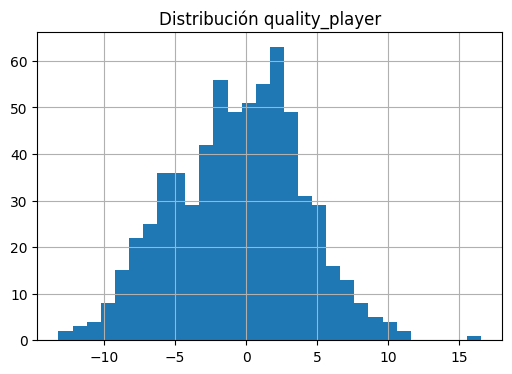

Outliers winsorizados (preview): 66


,TEAM_ID,PLAYER_ID,impact_raw,minutes_on,quality_player
22,1610612738,1628470,-15.4,201.0,-8.333999
23,1610612738,1631120,-23.7,93.0,-8.351792
40,1610612739,1641734,-31.2,75.0,-8.824060
52,1610612739,1641854,-16.4,513.0,-11.242748
54,1610612739,202684,-23.7,328.0,-13.221193


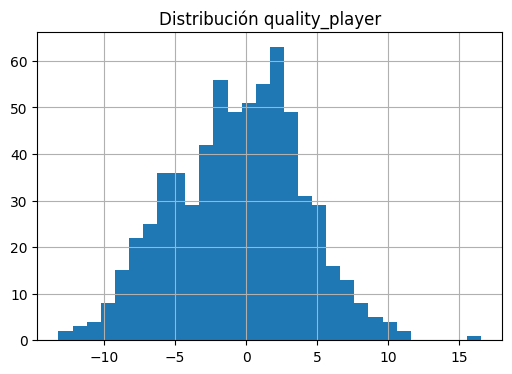

In [31]:
# Quality individual (On/Off)
if not df_on.empty and not df_off.empty:
    # Compatibilidad: los datasets on/off usan VS_PLAYER_ID en lugar de PLAYER_ID
    if 'VS_PLAYER_ID' in df_on.columns and 'PLAYER_ID' not in df_on.columns:
        print('Renombro VS_PLAYER_ID -> PLAYER_ID en df_on para calcular quality.')
        df_on = df_on.rename(columns={'VS_PLAYER_ID': 'PLAYER_ID'})
    if 'VS_PLAYER_ID' in df_off.columns and 'PLAYER_ID' not in df_off.columns:
        print('Renombro VS_PLAYER_ID -> PLAYER_ID en df_off para calcular quality.')
        df_off = df_off.rename(columns={'VS_PLAYER_ID': 'PLAYER_ID'})
    df_quality = feature_mod.compute_player_quality_from_onoff(
        df_on, df_off,
        m0_player_minutes=PARAMS['m0_player_minutes'],
        winsor_limits=PARAMS['winsor_limits'],
    )
    display(df_quality.head())
    _vals = df_quality['quality_player'].dropna()
    if not _vals.empty:
        ax = _vals.hist(bins=30, figsize=(6, 4))
        ax.set_title('Distribución quality_player')
        display(ax.figure)
        clip_lo, clip_hi = _vals.quantile(PARAMS['winsor_limits'])
        outliers = df_quality[(df_quality['quality_player'] < clip_lo) | (df_quality['quality_player'] > clip_hi)]
        print('Outliers winsorizados (preview):', len(outliers))
        display(outliers.head())
else:
    print('Sin on/off -> no se calcula quality.')
    df_quality = pd.DataFrame()


In [32]:
# Synergy por GROUP_ID
if not df_lineups.empty:
    df_synergy = feature_mod.compute_lineup_synergy_from_dashboard(
        df_lineups,
        M0_lineup_minutes=PARAMS['M0_lineup_minutes'],
    )
    top_team = df_synergy.groupby('TEAM_ID')['minutes_lineup'].sum().idxmax() if not df_synergy.empty else None
    if top_team is not None:
        display(df_synergy[df_synergy['TEAM_ID'] == top_team].sort_values('minutes_lineup', ascending=False).head(10))
    else:
        display(df_synergy.head())
else:
    print('Sin dashboard de lineups -> no hay synergy.')
    df_synergy = pd.DataFrame()


/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/02_FeatureFunctions.py:442: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_weighted_plus_minus = d.groupby('TEAM_ID').apply(


,TEAM_ID,GROUP_ID,synergy,minutes_lineup,plus_minus_lineup,plus_minus_team
3816,1610612752,-1626157-1628384-1628404-1628969-1628973-,63.019640,939.936667,76.0,22.350584
3817,1610612752,-1626157-1628384-1628404-1628969-1630540-,18.398157,185.323333,12.0,22.350584
3920,1610612752,-1628384-1628404-1628969-1628973-1630173-,7.957028,123.525000,-27.0,22.350584
3923,1610612752,-1628384-1628404-1628969-1628973-1630579-,13.947330,120.348333,-7.0,22.350584
3837,1610612752,-1626157-1628404-1628969-1628973-1630173-,17.783497,116.275000,6.0,22.350584
3775,1610612752,-1626157-1626166-1628384-1628404-1628969-,24.720840,97.686667,32.0,22.350584
3821,1610612752,-1626157-1628384-1628404-1628973-1630540-,31.715104,84.403333,65.0,22.350584
3796,1610612752,-1626157-1626166-1628404-1628969-1630540-,25.320309,83.421667,36.0,22.350584
3751,1610612752,-1626153-1626157-1628384-1628404-1628969-,18.230484,81.155000,3.0,22.350584
3941,1610612752,-1628384-1628969-1628973-1630173-1630540-,19.260754,69.901667,6.0,22.350584


In [33]:
# Scoring por partido
if not df_game_lineups.empty and not df_quality.empty and not df_synergy.empty:
    df_scores = feature_mod.build_lineup_scores_for_games(
        df_box=df_box,
        df_lineups=df_lineups,
        df_on=df_on,
        df_off=df_off,
        params=PARAMS,
    )
    display(df_scores.head())
else:
    print('Faltan insumos -> df_scores vacío.')
    df_scores = pd.DataFrame()


⚠️ Titulares incompletos (0) para GAME_ID=0022400476, TEAM_ID=1610612758. Uso top-5 por minutos.
⚠️ Titulares incompletos (0) para GAME_ID=0022400476, TEAM_ID=1610612763. Uso top-5 por minutos.
⚠️ Shrink fuerte para 132 jugadores (w<0.25). Ejemplos: [1641723, 1631342, 1631210, 1631120, 1641936].


/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/02_FeatureFunctions.py:442: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_weighted_plus_minus = d.groupby('TEAM_ID').apply(


⚠️ Alineación -201942-1628368-1628370-1628989-1631165- no encontrada para TEAM_ID=1610612758. Uso plus_minus_team como fallback.
⚠️ Alineación -1628991-1629634-1630217-1630590-1641744- no encontrada para TEAM_ID=1610612763. Uso plus_minus_team como fallback.
⚠️ Alineación -202681-202691-203939-203957-1630556- no encontrada para TEAM_ID=1610612742. Uso plus_minus_team como fallback.
⚠️ Alineación -202691-203939-203957-1630230-1630556- no encontrada para TEAM_ID=1610612742. Uso plus_minus_team como fallback.
⚠️ Alineación -1629012-1631131-1642262-1642268-1642271- no encontrada para TEAM_ID=1610612762. Uso plus_minus_team como fallback.
⚠️ Alineación -1628386-1629750-1641772-1641854-1642281- no encontrada para TEAM_ID=1610612739. Uso plus_minus_team como fallback.
⚠️ Alineación -1628981-1629628-1630534-1641711-1642367- no encontrada para TEAM_ID=1610612761. Uso plus_minus_team como fallback.
⚠️ Alineación -1628378-1628386-1629622-1630241-1630596- no encontrada para TEAM_ID=1610612739. Uso

,GAME_ID,HOME_TEAM_ID,AWAY_TEAM_ID,home_lineup_score,away_lineup_score,LINEUP_SCORE_DIFF,home_lineup_quality,away_lineup_quality,home_lineup_synergy,away_lineup_synergy,home_minutes_hist,away_minutes_hist,home_lineup_id,away_lineup_id,home_players,away_players
0,0022400001,1610612737,1610612738,0.453627,13.364508,-12.910881,-0.698603,0.596926,3.910319,51.667254,13.366667,268.138333,-203991-1630552-1630700-1630811-1642258-,-201143-201950-1627759-1628369-1628401-,"[203991, 1630552, 1630700, 1630811, 1642258]","[201143, 201950, 1627759, 1628369, 1628401]"
1,0022400002,1610612748,1610612765,-0.416144,-0.571427,0.155283,-0.336525,0.201623,-0.655003,-2.890579,58.083333,261.228333,-201567-1626179-1628389-1629312-1629639-,-202699-203501-1630595-1631093-1631105-,"[201567, 1626179, 1628389, 1629312, 1629639]","[202699, 203501, 1630595, 1631093, 1631105]"
2,0022400003,1610612753,1610612766,1.997133,1.839140,0.157994,1.776120,2.871762,2.660174,-1.258728,151.858333,13.616667,-203484-1629048-1630532-1630591-1641783-,-201959-1629684-1630163-1630182-1641706-,"[203484, 1629048, 1630532, 1630591, 1641783]","[201959, 1629684, 1630163, 1630182, 1641706]"
3,0022400004,1610612752,1610612755,16.502619,0.439305,16.063314,0.996945,1.116286,63.019640,-1.591637,939.936667,13.431667,-1626157-1628384-1628404-1628969-1628973-,-200768-202331-203954-1626162-1628997-,"[1626157, 1628384, 1628404, 1628969, 1628973]","[200768, 202331, 203954, 1626162, 1628997]"
4,0022400005,1610612749,1610612761,3.239876,0.976899,2.262978,2.216031,0.797228,6.311413,1.515911,18.950000,166.780000,-201572-203507-1627752-1631157-1631260-,-1627751-1629628-1630534-1630558-1641711-,"[201572, 203507, 1627752, 1631157, 1631260]","[1627751, 1629628, 1630534, 1630558, 1641711]"


Boxscore sin WL_NUM -> omito correlaciones.


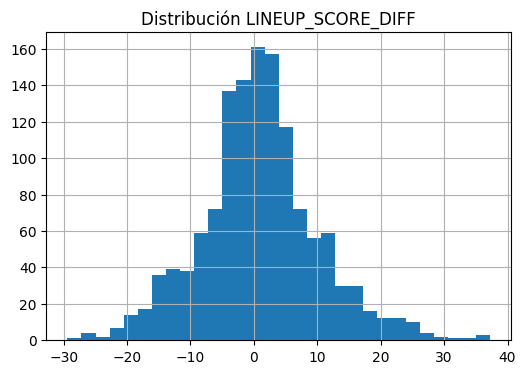

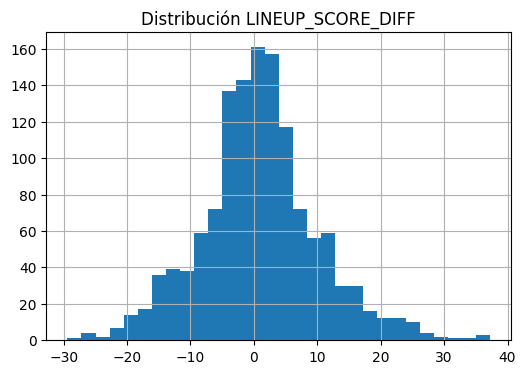

In [34]:
# Validación exploratoria (rápida)
if not df_scores.empty:
    if 'WL_NUM' in df_box.columns:
        df_wl = df_box[['GAME_ID', 'TEAM_ID', 'WL_NUM', 'MATCHUP']].drop_duplicates()
        df_home = df_wl[df_wl['MATCHUP'].str.contains('vs', case=False, na=False)][['GAME_ID', 'WL_NUM']].rename(columns={'WL_NUM': 'WL_HOME'})
        df_val = df_scores.merge(df_home, on='GAME_ID', how='left')
        if df_val['WL_HOME'].notna().any():
            corr_pearson = df_val[['WL_HOME', 'LINEUP_SCORE_DIFF']].corr(method='pearson').iloc[0, 1]
            corr_spearman = df_val[['WL_HOME', 'LINEUP_SCORE_DIFF']].corr(method='spearman').iloc[0, 1]
            print(f'Pearson(WL_HOME, diff) = {corr_pearson:.3f}')
            print(f'Spearman(WL_HOME, diff) = {corr_spearman:.3f}')
        else:
            print('Sin WL_HOME -> omito correlaciones.')
    else:
        print('Boxscore sin WL_NUM -> omito correlaciones.')
    ax = df_scores['LINEUP_SCORE_DIFF'].hist(bins=30, figsize=(6, 4))
    ax.set_title('Distribución LINEUP_SCORE_DIFF')
    display(ax.figure)
else:
    print('Sin df_scores -> omito validación.')


In [35]:
# Export
if not df_scores.empty:
    out_path = Path(PATHS['out'])
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df_scores.to_parquet(out_path, index=False)
    print(f'Guardado OK -> {out_path} ({df_scores.shape[0]} filas, {df_scores.shape[1]} columnas)')
else:
    print('df_scores vacío -> no se exporta.')


Guardado OK -> /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/features/lineup_scores.parquet (1312 filas, 16 columnas)


## Notas de predicción pre-partido

Para usar este bloque en predicciones previas al juego, filtra los dataframes de entrada por `GAME_DATE` < fecha del partido objetivo antes de calcular quality y synergy. Mantén el formato canónico de `GROUP_ID` y evita mezclar minutos futuros para prevenir fuga de información.
